# Rows that multiply

**Week 2, Tuesday. Round 1 of 3, notebook 1 of 4.** By the end of this notebook you can say what
each of the four joins keeps and drops, explain why a naive join on Kalpa's Q2 orders reports
collections at almost twice bookings, and rebuild the number at order grain so that 462 rows go in
and 462 rows come out.

> **The client asks.** "Booked revenue is not collected revenue. Some orders are paid in two
> instalments, some are refunded, some were never paid at all. Show me, order by order, what we
> actually collected against what we booked in Q2. If there is a gap, I want to know which orders
> and which channel."
>
> Anand Iyer, finance controller, Kalpa Retail

> **Kavya's review.** "A join is a multiplication until you prove it is not. Tell me the grain of
> each table before you tell me a total."

Monday's suite answered from the orders table alone: Q2 booked Rs 9,84,00,000 over 462 orders,
with every order counted whatever its status. Today a second table arrives, the payments feed, and
the first thing a second table does is change how many rows you are adding up.

**Setup.** The next cell finds the helper by walking up from this folder, connects to the Kalpa
warehouse, and creates two tiny invented tables, `tiny_orders` and `tiny_payments`, as TEMP tables
on this notebook's one connection, so they vanish when the kernel stops and the warehouse is never
touched. The same tables are in `sql/C2_W02_D02_01_tiny_tables_STUDENT.sql`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

TINY = """
DROP TABLE IF EXISTS tiny_orders, tiny_payments;
CREATE TEMP TABLE tiny_orders (order_id text PRIMARY KEY, channel text, amount numeric(12, 2), status text);
CREATE TEMP TABLE tiny_payments (payment_id text PRIMARY KEY, order_id text, paid_date date,
                                 amount numeric(12, 2), instalment_no integer);
INSERT INTO tiny_orders VALUES
    ('T-1', 'app', 1000, 'delivered'), ('T-2', 'web', 2000, 'delivered'),
    ('T-3', 'store', 1500, 'delivered'), ('T-4', 'app', 800, 'delivered'),
    ('T-5', 'store', 500, 'delivered');
INSERT INTO tiny_payments VALUES
    ('P-1', 'T-1', '2026-07-03', 1000, 1), ('P-2', 'T-2', '2026-07-05', 1200, 1),
    ('P-3', 'T-2', '2026-08-05', 800, 2), ('P-4', 'T-3', '2026-07-09', 1500, 1),
    ('P-5', 'T-3', '2026-07-09', 1500, 1), ('P-6', 'T-5', '2026-07-12', 500, 1),
    ('P-7', 'T-9', '2026-07-14', 600, 1);
"""

from decimal import Decimal

conn = kit.connect()
conn.autocommit = True
with conn.cursor() as cur:
    cur.execute(TINY)          # invented tables, TEMP, so they vanish with this session


def run(query, params=None):
    """Run a query on this notebook's one connection and return its rows as dictionaries."""
    return kit.sql(query, params, conn=conn)


def show(rows, caption="", money=()):
    """Set the rows as the kit's table, with the named columns in Rs and NULL written out."""
    headers = list(rows[0]) if rows else ["result"]
    body = []
    for r in rows:
        line = []
        for h in headers:
            v = r[h]
            if v is None:
                line.append("NULL")
            elif h in money:
                line.append(kit.rupees(v))
            elif isinstance(v, Decimal):
                line.append(int(v) if v == v.to_integral_value() else float(v))
            else:
                line.append(v)
        body.append(line)
    kit.table(headers, body or [["no rows"]], caption)


def crore(v):
    """A chart label in crore, since eight-digit rupee labels do not fit under a column."""
    return f"{float(v) / 1e7:.2f}"

print("warehouse connected; tiny_orders holds", run("SELECT count(*) AS n FROM tiny_orders")[0]["n"],
      "invented orders and tiny_payments holds", run("SELECT count(*) AS n FROM tiny_payments")[0]["n"], "invented payments")

warehouse connected; tiny_orders holds 5 invented orders and tiny_payments holds 7 invented payments


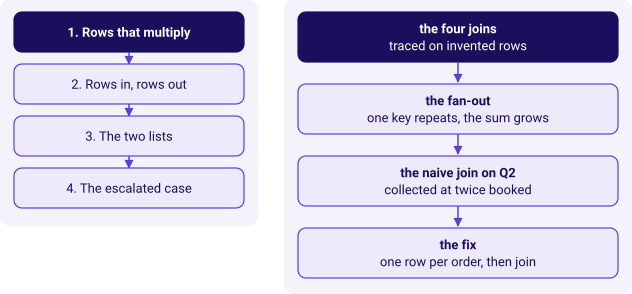

In [2]:
kit.side_by_side(
    kit.ladder(["Rows that multiply", "Rows in, rows out", "The two lists", "The escalated case"],
               lit=0, show=False),
    kit.vflow(["the four joins\ntraced on invented rows",
               "the fan-out\none key repeats, the sum grows",
               "the naive join on Q2\ncollected at twice booked",
               "the fix\none row per order, then join"], lit=0, show=False),
)

## 1. Every join answers a question about the rows that do not match

The grain comes first. `tiny_orders` holds one row per order and `tiny_payments` holds one row per
payment, so an order paid in two instalments owns two payment rows. The invented tables are built
to carry every case Anand named: T-2 is paid in two instalments, T-3 has its one instalment posted
twice by a gateway retry, T-4 was never paid, and P-7 is a payment whose order is not in the
orders table.

**Predict before you run.** Five orders are joined to seven payments with an INNER JOIN on
`order_id`. How many rows come back? a) 5, one per order; b) 6; c) 7, one per payment; d) 8.

In [3]:
inner_rows = run("""
SELECT o.order_id, o.amount AS booked, p.payment_id, p.amount AS paid
FROM tiny_orders o
JOIN tiny_payments p ON p.order_id = o.order_id
ORDER BY o.order_id, p.payment_id
""")
show(inner_rows, "INNER JOIN on the invented tables: one row per matching pair", money=["booked", "paid"])

order_id,booked,payment_id,paid
T-1,"Rs 1,000",P-1,"Rs 1,000"
T-2,"Rs 2,000",P-2,"Rs 1,200"
T-2,"Rs 2,000",P-3,Rs 800
T-3,"Rs 1,500",P-4,"Rs 1,500"
T-3,"Rs 1,500",P-5,"Rs 1,500"
T-5,Rs 500,P-6,Rs 500


**What happened.** The answer is b, six rows. INNER keeps a row for every pair of an order and a
payment that share an `order_id`, so T-2 appears twice (two instalments), T-3 appears twice (the
retry), T-4 is gone because nothing matched it, and P-7 is gone because no order matched it. The
join did not ask whether you wanted T-4 in Anand's report; it dropped it.

The other three joins differ only in what they do with the rows that find no partner, which is
exactly the question to ask before choosing one.

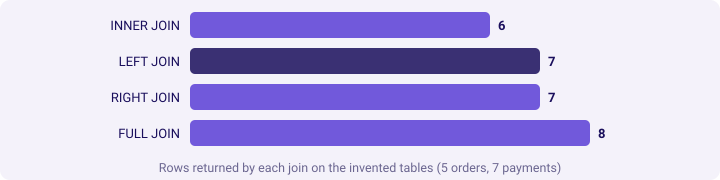

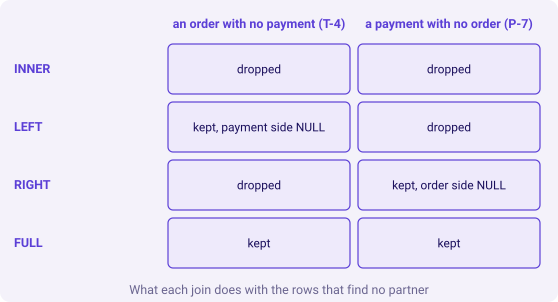

In [4]:
counts = run("""
SELECT 'INNER' AS join_type, count(*) AS row_count
FROM tiny_orders o JOIN tiny_payments p ON p.order_id = o.order_id
UNION ALL
SELECT 'LEFT', count(*) FROM tiny_orders o LEFT JOIN tiny_payments p ON p.order_id = o.order_id
UNION ALL
SELECT 'RIGHT', count(*) FROM tiny_orders o RIGHT JOIN tiny_payments p ON p.order_id = o.order_id
UNION ALL
SELECT 'FULL', count(*) FROM tiny_orders o FULL JOIN tiny_payments p ON p.order_id = o.order_id
""")
rows_by_join = {r["join_type"]: r["row_count"] for r in counts}
kit.bars([(f"{k} JOIN", v) for k, v in rows_by_join.items()], lit=[1],
         title="Rows returned by each join on the invented tables (5 orders, 7 payments)")
kit.matrix(["INNER", "LEFT", "RIGHT", "FULL"],
           ["an order with no payment (T-4)", "a payment with no order (P-7)"],
           [["dropped", "dropped"], ["kept, payment side NULL", "dropped"],
            ["dropped", "kept, order side NULL"], ["kept", "kept"]],
           title="What each join does with the rows that find no partner")

In [5]:
kit.check("INNER returns 6 rows: every matching pair, T-2 and T-3 twice each", rows_by_join["INNER"] == 6,
          f'{rows_by_join["INNER"]} rows')
kit.check("LEFT adds exactly the one unpaid order to INNER", rows_by_join["LEFT"] - rows_by_join["INNER"] == 1,
          f'{rows_by_join["LEFT"]} against {rows_by_join["INNER"]}')
kit.check("RIGHT adds exactly the one payment with no order", rows_by_join["RIGHT"] - rows_by_join["INNER"] == 1,
          f'{rows_by_join["RIGHT"]} against {rows_by_join["INNER"]}')
kit.check("FULL keeps both kinds of orphan", rows_by_join["FULL"] == rows_by_join["INNER"] + 2,
          f'{rows_by_join["FULL"]} rows')

## 2. A key that repeats on one side multiplies the other side's rows

Anand's question needs booked and collected per order. The hurried move is to join and sum the
order amount, treating "orders that have a payment" as collected. Booked on the invented tables is
5,800 over five orders.

**Predict before you run.** What does `SUM(o.amount)` over the INNER JOIN return? a) 5,000, the
paid orders once each; b) 5,800, booked; c) 6,500, the payments; d) 8,500.

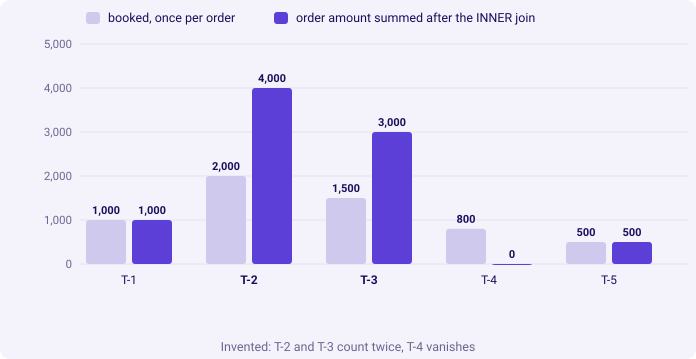

In [6]:
per_order = run("""
SELECT o.order_id,
       o.amount AS booked_once,
       coalesce(sum(o.amount) FILTER (WHERE p.payment_id IS NOT NULL), 0) AS summed_after_join,
       count(p.payment_id) AS payment_rows
FROM tiny_orders o
LEFT JOIN tiny_payments p ON p.order_id = o.order_id
GROUP BY o.order_id, o.amount
ORDER BY o.order_id
""")
after_join = run("SELECT sum(o.amount) AS s FROM tiny_orders o JOIN tiny_payments p ON p.order_id = o.order_id")[0]["s"]
booked_tiny = run("SELECT sum(amount) AS s FROM tiny_orders")[0]["s"]
kit.columns([r["order_id"] for r in per_order],
            [("booked, once per order", [float(r["booked_once"]) for r in per_order]),
             ("order amount summed after the INNER join", [float(r["summed_after_join"]) for r in per_order])],
            lit=[1, 2], title="Invented: T-2 and T-3 count twice, T-4 vanishes")
kit.stats([(f"{int(after_join):,}", "summed after the join", "the order amount, once per payment row"),
           (f"{int(booked_tiny):,}", "booked", "the order amount, once per order"),
           (f"{after_join / booked_tiny:.2f}", "times", "the join's total over booked")])

**What happened.** The answer is d, 8,500, which is 1.47 times the 5,800 booked. The sum went up
for two different reasons and down for a third, all inside one number: T-2 counts twice because it
was paid in two instalments, T-3 counts twice because the gateway posted its one payment twice, and
T-4 is missing because it was never paid. Nothing in the result is a wrong row, which is why the
number looks trustworthy.

In [7]:
extra = sum((r["payment_rows"] - 1) * r["booked_once"] for r in per_order if r["payment_rows"] > 1)
missing = sum(r["booked_once"] for r in per_order if r["payment_rows"] == 0)
kit.check("the join's total is booked plus the repeated orders less the unpaid one",
          after_join == booked_tiny + extra - missing, f"{int(after_join):,} = {int(booked_tiny):,} + {int(extra):,} - {int(missing):,}")
kit.check("the INNER join returns more rows than there are orders", rows_by_join["INNER"] > len(per_order),
          f'{rows_by_join["INNER"]} rows from {len(per_order)} orders')

## 3. The naive join on Kalpa's Q2 reports collections at almost twice bookings

Now the warehouse. `orders` holds one row per order; `payments` holds one row per payment, 1,428 of
them, and large invoices are settled in two instalments, so `order_id` repeats in `payments`. The
data platform lead has also said the feed sometimes double-posts when the gateway retries.

**The plausible wrong answer.** A hurried analyst writes "collected" as the value of the Q2 orders
that have a payment, which is the query below, from `sql/C2_W02_D02_02_fanout_STUDENT.sql`.

**Predict before you run.** Against Rs 9,84,00,000 booked, the query returns: a) a little less than
booked, because some orders are unpaid; b) exactly booked; c) close to double booked; d) about half
of booked.

In [8]:
wrong = run("""
SELECT sum(o.amount) AS collected_as_reported
FROM orders o
JOIN payments p ON p.order_id = o.order_id
WHERE o.quarter = 'Q2'
""")[0]["collected_as_reported"]
booked = run("SELECT sum(amount) AS s FROM orders WHERE quarter = 'Q2'")[0]["s"]
kit.stats([(kit.rupees(wrong), "collected, as reported", "SUM(o.amount) after the join"),
           (kit.rupees(booked), "booked", "Q2 orders, from orders alone"),
           (f"{wrong / booked:.2f}", "times", "reported collected over booked")])

**Why it is wrong.** The answer is c: Rs 19,29,04,410, which is 1.96 times the Rs 9,84,00,000
booked. Sent to Anand, it says collections are running ahead of bookings, and the decision it
invites is to stand the collections team down for the quarter. Every row it summed is a real Q2
order with a real payment; the mistake is the grain. Each order is counted once per payment row, so
every order settled in two instalments is counted twice.

The check that exposes it is the row count, orders in against rows out, and the payment rows per
order that explain the difference.

orders_in,rows_out,orders_with_two_or_more,most_rows_for_one_order,payment_rows_in_feed
462,678,216,2,1428


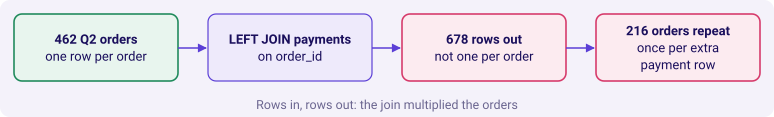

In [9]:
grain = run("""
WITH q2 AS (SELECT order_id FROM orders WHERE quarter = 'Q2'),
     per_order AS (SELECT p.order_id, count(*) AS payment_rows
                   FROM payments p JOIN q2 ON q2.order_id = p.order_id GROUP BY p.order_id)
SELECT (SELECT count(*) FROM q2) AS orders_in,
       (SELECT count(*) FROM orders o LEFT JOIN payments p ON p.order_id = o.order_id
         WHERE o.quarter = 'Q2') AS rows_out,
       (SELECT count(*) FROM per_order WHERE payment_rows > 1) AS orders_with_two_or_more,
       (SELECT max(payment_rows) FROM per_order) AS most_rows_for_one_order,
       (SELECT count(*) FROM payments) AS payment_rows_in_feed
""")[0]
show([grain], "The grain check on Q2: orders in, rows out, and what repeats")
kit.flow([f"{grain['orders_in']} Q2 orders\none row per order",
          "LEFT JOIN payments\non order_id",
          f"{grain['rows_out']} rows out\nnot one per order",
          f"{grain['orders_with_two_or_more']} orders repeat\nonce per extra payment row"],
         kinds=["good", "plain", "bad", "bad"], title="Rows in, rows out: the join multiplied the orders")

In [10]:
kit.check("rows out exceed orders in, so the join fanned out", grain["rows_out"] > grain["orders_in"],
          f'{grain["rows_out"]} rows from {grain["orders_in"]} orders')
kit.check("the extra rows are exactly the repeated orders' extra payment rows",
          grain["rows_out"] - grain["orders_in"] == grain["orders_with_two_or_more"] * (grain["most_rows_for_one_order"] - 1),
          f'{grain["rows_out"] - grain["orders_in"]} extra rows')
kit.check("the reported collected is close to double booked, which no business collects", wrong / booked > 1.9,
          f"{wrong / booked:.2f} times")

The size of Q2's orders shows why the doubling is so large in rupees. Most orders are small, and
the rupees sit in a few hundred-thousand-rupee and crore-sized invoices, which are the orders large
enough to be settled in two instalments, so the rows the join repeats are the heaviest ones.

size_band,orders,booked
"under Rs 10,000",371,"Rs 8,15,400"
"Rs 10,000 to Rs 10 lakh",53,"Rs 2,91,90,000"
Rs 10 lakh and more,38,"Rs 6,83,94,600"


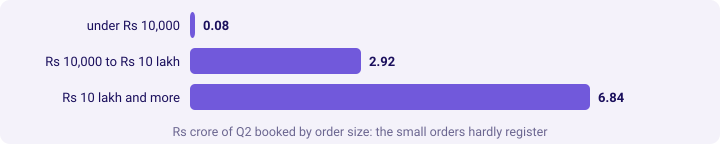

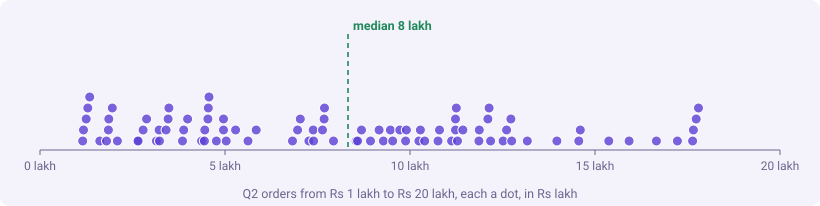

In [11]:
bands = run("""
SELECT CASE WHEN amount < 10000 THEN 'under Rs 10,000'
            WHEN amount < 1000000 THEN 'Rs 10,000 to Rs 10 lakh'
            ELSE 'Rs 10 lakh and more' END AS size_band,
       count(*) AS orders, sum(amount) AS booked
FROM orders WHERE quarter = 'Q2'
GROUP BY 1 ORDER BY min(amount)
""")
show(bands, "Q2 orders by size", money=["booked"])
kit.bars([(r["size_band"], float(r["booked"])) for r in bands], fmt=crore,
         title="Rs crore of Q2 booked by order size: the small orders hardly register")
large = [float(r["amount"]) / 1e5 for r in run(
    "SELECT amount FROM orders WHERE quarter = 'Q2' AND amount BETWEEN 100000 AND 2000000 ORDER BY amount")]
kit.strip(large, markers=[("median", large[len(large) // 2], "good")], lo=0, hi=20,
          fmt=lambda v: f"{v:,.0f} lakh", title="Q2 orders from Rs 1 lakh to Rs 20 lakh, each a dot, in Rs lakh")

In [12]:
small = bands[0]
kit.check("most Q2 orders are under Rs 10,000", small["orders"] > 462 / 2, f'{small["orders"]} of 462 orders')
kit.check("those small orders hold under one percent of booked", small["booked"] / booked < 0.01,
          f'{float(small["booked"] / booked):.1%} of booked')

## 4. Booked and collected side by side need one row per order first

The room's harder variant puts both numbers in one report by channel, from one LEFT JOIN, which
looks careful because LEFT keeps every order.

**Predict before you run.** The report says Q2 is about half collected. What is wrong with it?
a) nothing, half the orders are unpaid; b) booked is inflated by the fan-out, while the payments
column is summed once per payment and is not; c) collected is inflated and booked is right; d) the
channels are mislabelled.

channel,rows_out,booked_as_reported,collected_as_reported,pct_collected
app,229,"Rs 8,50,44,740","Rs 4,25,89,770",50.1
store,226,"Rs 6,32,06,360","Rs 3,11,96,760",49.4
web,223,"Rs 4,64,08,240","Rs 2,28,79,290",49.3


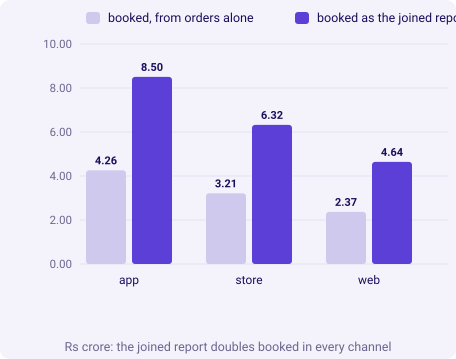

In [13]:
both = run("""
SELECT o.channel,
       count(*) AS rows_out,
       sum(o.amount) AS booked_as_reported,
       sum(p.amount) AS collected_as_reported,
       round(100 * sum(p.amount) / sum(o.amount), 1) AS pct_collected
FROM orders o
LEFT JOIN payments p ON p.order_id = o.order_id
WHERE o.quarter = 'Q2'
GROUP BY o.channel
ORDER BY o.channel
""")
show(both, "The both-columns report from one LEFT JOIN, by channel",
     money=["booked_as_reported", "collected_as_reported"])
booked_by_channel = {r["channel"]: r["booked"] for r in run(
    "SELECT channel, sum(amount) AS booked FROM orders WHERE quarter = 'Q2' GROUP BY channel ORDER BY channel")}
kit.columns([r["channel"] for r in both],
            [("booked, from orders alone", [float(booked_by_channel[r["channel"]]) for r in both]),
             ("booked as the joined report says", [float(r["booked_as_reported"]) for r in both])],
            fmt=crore, title="Rs crore: the joined report doubles booked in every channel")

**What happened.** The answer is b. The report's booked column totals Rs 19,46,59,340 because every
two-instalment order is counted twice, while its collected column, Rs 9,66,65,820, sums each payment
row once, so the 49.7 percent it prints is a real payment total over an inflated denominator. The
decision it invites is a collections panic over roughly Rs 9.8 crore that nobody owes.

**The fix.** Bring payments to one row per order in a CTE, then join at the same grain. Rows in must
equal rows out, and booked must come back to Monday's number.

channel,rows_out,booked,paid_as_posted
app,153,"Rs 4,25,90,270","Rs 4,25,89,770"
store,159,"Rs 3,21,48,730","Rs 3,11,96,760"
web,150,"Rs 2,36,61,000","Rs 2,28,79,290"


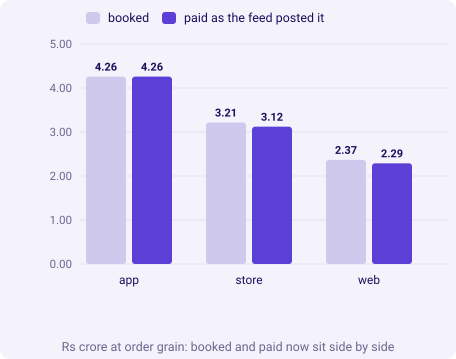

In [14]:
fixed = run("""
WITH paid_per_order AS (
    SELECT order_id, sum(amount) AS paid, count(*) AS payment_rows
    FROM payments
    GROUP BY order_id
)
SELECT o.channel,
       count(*) AS rows_out,
       sum(o.amount) AS booked,
       sum(coalesce(pp.paid, 0)) AS paid_as_posted
FROM orders o
LEFT JOIN paid_per_order pp ON pp.order_id = o.order_id
WHERE o.quarter = 'Q2'
GROUP BY o.channel
ORDER BY o.channel
""")
show(fixed, "At order grain: one row per Q2 order, by channel", money=["booked", "paid_as_posted"])
kit.columns([r["channel"] for r in fixed],
            [("booked", [float(r["booked"]) for r in fixed]),
             ("paid as the feed posted it", [float(r["paid_as_posted"]) for r in fixed])],
            fmt=crore, title="Rs crore at order grain: booked and paid now sit side by side")

In [15]:
rows_out = sum(r["rows_out"] for r in fixed)
booked_fixed = sum(r["booked"] for r in fixed)
posted_fixed = sum(r["paid_as_posted"] for r in fixed)
kit.check("rows out equal the 462 orders in", rows_out == grain["orders_in"] == 462, f"{rows_out} rows")
kit.check("booked after the join equals booked from orders alone", booked_fixed == booked,
          kit.rupees(booked_fixed))
kit.check("the payments total does not change with the grain, only the order total did",
          posted_fixed == sum(r["collected_as_reported"] for r in both), kit.rupees(posted_fixed))
kit.check("paid as posted sits below booked, as a business that is owed money should",
          posted_fixed < booked_fixed, f"{posted_fixed / booked_fixed:.1%} of booked")

> **Kavya's review.** "A join is a multiplication until you prove it is not. Tell me the grain of
> each table before you tell me a total."

The fixed report is the first number in this round that could go to Anand, and it is still labelled
"as posted" on purpose: the feed can post one payment twice, and posted sits below booked by less
than two percent of the quarter. Round 2 asks what that difference is made of, and makes the row
count the thing written above every joined number.

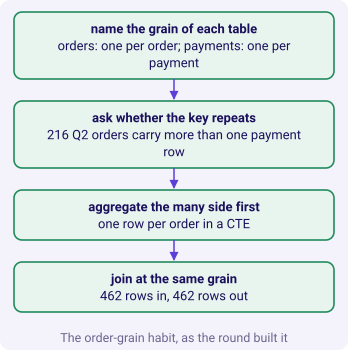

What you can now say,The evidence
"INNER keeps pairs, LEFT keeps every order, RIGHT every payment, FULL both","6, 7, 7 and 8 rows on the invented tables"
The naive join doubled collected,"Rs 19,29,04,410 against Rs 9,84,00,000 booked"
The both-columns report doubled booked,"Rs 19,46,59,340 and a false 49.7 percent"
At order grain the rows and booked reconcile,"462 rows, Rs 9,84,00,000 booked"


In [16]:
kit.vflow(["name the grain of each table\norders: one per order; payments: one per payment",
           "ask whether the key repeats\n216 Q2 orders carry more than one payment row",
           "aggregate the many side first\none row per order in a CTE",
           "join at the same grain\n462 rows in, 462 rows out"],
          kinds=["good", "good", "good", "good"], title="The order-grain habit, as the round built it")
kit.table(["What you can now say", "The evidence"],
          [["INNER keeps pairs, LEFT keeps every order, RIGHT every payment, FULL both",
            "6, 7, 7 and 8 rows on the invented tables"],
           ["The naive join doubled collected", "Rs 19,29,04,410 against Rs 9,84,00,000 booked"],
           ["The both-columns report doubled booked", "Rs 19,46,59,340 and a false 49.7 percent"],
           ["At order grain the rows and booked reconcile", f"{rows_out} rows, {kit.rupees(booked_fixed)} booked"]],
          caption="What round 1 established")

### In the interview

**[S] INNER against LEFT join: what does each drop or keep?** "INNER keeps only the rows that find
a partner on both sides, once per matching pair. LEFT keeps every row of the left table, and where
nothing matches it fills the right side with NULLs. So the question that chooses between them is
about the rows that do not match: if an order with no payment belongs in the answer, and for
collections it does because it is the gap, the join has to be LEFT. I also say that both joins
repeat a left row once per match, so neither protects you from a key that repeats on the right."

**[S] Your join grew the row count; name the cause and the check.** "The join key repeats on at
least one side, so each row on the other side is copied once per match. Here an order paid in two
instalments has two payment rows, so the order appears twice. The check is rows in against rows
out: count the left table, count the join, and explain the difference with a GROUP BY on the key
that shows how many rows repeat and how often. The fix is to aggregate the many side to the grain
of the question before joining."

**[F] Revenue doubled after a join and every row looks fine; where do you look?** "At the grain,
before the rows. Every row being real is the signature of a fan-out, because a fan-out repeats real
rows. I count rows in and rows out, check whether the key is unique on the side I joined to, and
compare the summed column to its total from the source table alone. On Kalpa's Q2 the order amount
summed after the join was 1.96 times booked, and the order count per payment row explained all of
it."

**[S] What does a FULL OUTER JOIN add, and when would you reach for it?** "It keeps the unmatched
rows from both sides, so it is the join for a reconciliation between two systems where either side
can hold records the other lacks, such as orders against a payments feed. I use it to find both
kinds of orphan in one pass, then split them, since an unpaid order and a payment with no order go
to different people."

**[S] When is an INNER join the honest choice?** "When the question is only about matched pairs,
such as the average time from order to payment for orders that were paid. Then an unmatched row has
no answer to give, and dropping it is the definition, which I state beside the number. It is the
wrong choice whenever the unmatched rows are part of what the stakeholder asked for."

### Depth: why DISTINCT does not repair a fan-out

A common reflex is `SUM(DISTINCT o.amount)`. It removes repeats of the same amount, which also
removes two different orders that happen to share a value, and it cannot tell a second instalment
from a retry, so the total it prints is wrong in a way no check catches. `COUNT(DISTINCT
o.order_id)` is safe for counting orders, because the key is unique per order, which is exactly why
the fix works on keys and grain rather than on values. The reliable pattern is the one this round
used: aggregate the many side to one row per key in a CTE, join, then check rows in against rows
out.

The same trap has a larger form. Join orders to payments and to refunds in one query and each order
is copied once per payment times once per refund, so two fan-outs multiply each other. Aggregate
each child table to order grain separately, then join the aggregates.

Written references: PostgreSQL 16 documentation, 2.6 Joins Between Tables,
https://www.postgresql.org/docs/16/tutorial-join.html (verified 29 Sep 2026).
Video: "SQL Joins Basics (Visually Explained)", Data with Baraa,
https://www.youtube.com/watch?v=aY7z4HcHm5M (verified 29 Sep 2026).

In [17]:
kit.check_summary()
print("Next: round 2 makes the row count a habit and builds the bridge from booked to what the feed posted.")

Next: round 2 makes the row count a habit and builds the bridge from booked to what the feed posted.
